<a href="https://colab.research.google.com/github/Harshitha-code07/Multi-Task-AI-Profiler-for-Global-Health-SDG-3-/blob/main/ML_PROJECT_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, VotingRegressor, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

In [ ]:
# ---------------------------------------------------------
# 1. DATA WRANGLING & PREPARATION
# ---------------------------------------------------------
print("Loading and preparing data...")
# UPDATE THIS PATH to where your CSV is located in Colab
file_path = '/content/Life Expectancy Data.csv'
df = pd.read_csv(file_path)

# Handle Categorical Data (Convert 'Status' from text to numbers)
le_status = LabelEncoder()
df['Status'] = le_status.fit_transform(df['Status']) # 0 = Developed, 1 = Developing

# We will drop 'Country' and 'Year' for the models to focus purely on health metrics
X_raw = df.drop(columns=['Country', 'Year'])

# Handle Missing Numerical Data (WHO dataset has lots of blanks!)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_raw), columns=X_raw.columns)

# Standardize the data (Crucial for PCA, SVM, Ridge, Lasso, and KNN)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X_imputed.columns)

Loading and preparing data...



Performing PCA and Clustering...


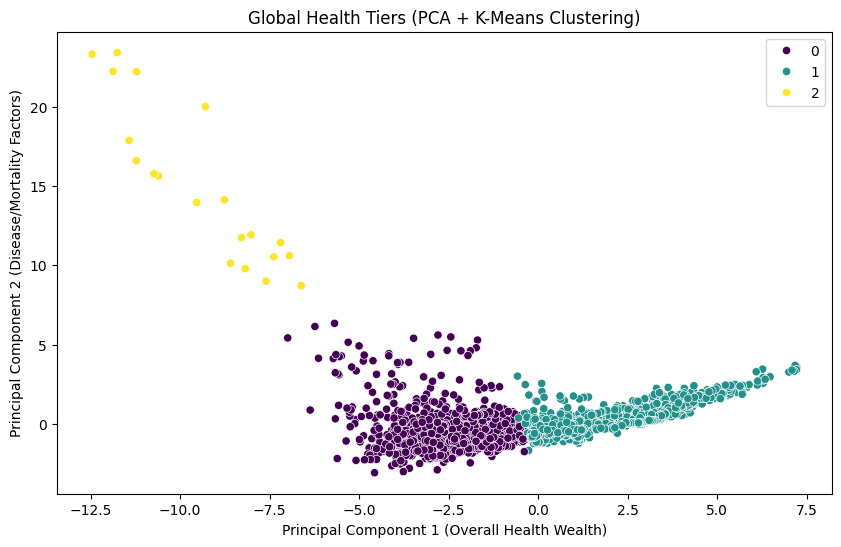

In [ ]:
# ---------------------------------------------------------
# 2. FEATURE EXTRACTION & CLUSTERING (Unsupervised)
# ---------------------------------------------------------
print("\nPerforming PCA and Clustering...")

# Reduce 20+ features down to 2 just for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Cluster countries into 3 distinct "Health Tiers"
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Plot the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='viridis')
plt.title('Global Health Tiers (PCA + K-Means Clustering)')
plt.xlabel('Principal Component 1 (Overall Health Wealth)')
plt.ylabel('Principal Component 2 (Disease/Mortality Factors)')
plt.show()

In [ ]:
import pandas as pd

# Extract the mathematical weights (loadings) PCA used to build PC1 and PC2
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=X_scaled.columns)

print("--- What drives Principal Component 1 (PC1)? ---")
# Sort by the highest positive weights
print(loadings.sort_values(by='PC1', ascending=False)['PC1'].head(10))

print("\n--- What drives Principal Component 2 (PC2)? ---")
# Sort by the highest positive weights
print(loadings.sort_values(by='PC2', ascending=False)['PC2'].head(10))

--- What drives Principal Component 1 (PC1)? ---
Life expectancy                    0.327051
Schooling                          0.306229
Income composition of resources    0.290079
 BMI                               0.261071
Alcohol                            0.226227
GDP                                0.223559
percentage expenditure             0.208959
Diphtheria                         0.206053
Polio                              0.202388
Total expenditure                  0.136954
Name: PC1, dtype: float64

--- What drives Principal Component 2 (PC2)? ---
infant deaths                      0.489228
under-five deaths                  0.482598
Population                         0.384270
Measles                            0.313832
GDP                                0.182733
percentage expenditure             0.181683
 thinness 5-9 years                0.171781
 thinness  1-19 years              0.169208
Income composition of resources    0.166271
Life expectancy                    0.15


--- Training Regression Ensemble (Target: Life Expectancy) ---
Regression R2 Score (Accuracy of Age Prediction): 0.8963


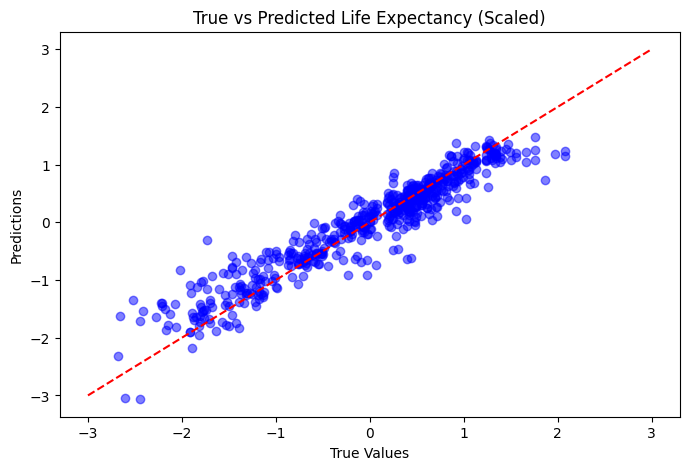

In [ ]:
# ---------------------------------------------------------
# 3. REGRESSION ENSEMBLE: Predict Life Expectancy (Age)
# ---------------------------------------------------------
print("\n--- Training Regression Ensemble (Target: Life Expectancy) ---")
# Setup target (y) and features (X)
y_reg = X_scaled['Life expectancy ']
X_reg = X_scaled.drop(columns=['Life expectancy '])

X_train_R, X_test_R, y_train_R, y_test_R = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Build Regression Models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Create Voting Regressor
reg_ensemble = VotingRegressor([('Ridge', ridge), ('Lasso', lasso), ('RF', rf_reg)])
reg_ensemble.fit(X_train_R, y_train_R)

# Evaluate Regression
reg_pred = reg_ensemble.predict(X_test_R)
print(f"Regression R2 Score (Accuracy of Age Prediction): {r2_score(y_test_R, reg_pred):.4f}")

# Plot Regression Results
plt.figure(figsize=(8, 5))
plt.scatter(y_test_R, reg_pred, alpha=0.5, color='blue')
plt.plot([-3, 3], [-3, 3], color='red', linestyle='--') # Perfect prediction line
plt.title('True vs Predicted Life Expectancy (Scaled)')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.show()

In [ ]:
# ---------------------------------------------------------
# 4. CLASSIFICATION ENSEMBLE: Predict Status (Developed/Developing)
# ---------------------------------------------------------
print("\n--- Training Classification Ensemble (Target: Economic Status) ---")
# Setup target (y) and features (X)
y_clf = df['Status'] # Unscaled original labels (0 or 1)
X_clf = X_scaled.drop(columns=['Status'])

X_train_C, X_test_C, y_train_C, y_test_C = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Build Classification Models
log_reg = LogisticRegression()
svm_clf = SVC(probability=True, kernel='linear')
knn_clf = KNeighborsClassifier(n_neighbors=5)

# Create Voting Classifier
clf_ensemble = VotingClassifier([('LogReg', log_reg), ('SVM', svm_clf), ('KNN', knn_clf)], voting='soft')
clf_ensemble.fit(X_train_C, y_train_C)

# Evaluate Classification
clf_pred = clf_ensemble.predict(X_test_C)
print(f"Classification Accuracy: {accuracy_score(y_test_C, clf_pred) * 100:.2f}%\n")
print(classification_report(y_test_C, clf_pred, target_names=['Developed', 'Developing']))


--- Training Classification Ensemble (Target: Economic Status) ---
Classification Accuracy: 94.39%

              precision    recall  f1-score   support

   Developed       0.80      0.89      0.84        97
  Developing       0.98      0.96      0.97       491

    accuracy                           0.94       588
   macro avg       0.89      0.92      0.90       588
weighted avg       0.95      0.94      0.95       588



In [ ]:
# ---------------------------------------------------------
#5: Education Level Predictor (Classification)
# ---------------------------------------------------------
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

print("\n--- Training Education Level Predictor ---")
# Create a binary target: 1 if Schooling is above median, 0 if below
median_schooling = df['Schooling'].median()
y_edu = (df['Schooling'] > median_schooling).astype(int)

# Drop 'Schooling' from features so the model can't cheat!
X_edu = X_scaled.drop(columns=['Schooling'])

X_train_E, X_test_E, y_train_E, y_test_E = train_test_split(X_edu, y_edu, test_size=0.2, random_state=42)

# Build a Decision Tree and Naive Bayes
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
nb_clf = GaussianNB()



# Train and Predict with Decision Tree
dt_clf.fit(X_train_E, y_train_E)
dt_pred = dt_clf.predict(X_test_E)

# Train and Predict with Naive Bayes
nb_clf.fit(X_train_E, y_train_E)
nb_pred = nb_clf.predict(X_test_E)

print(f"Decision Tree Accuracy (Education): {accuracy_score(y_test_E, dt_pred) * 100:.2f}%")
print(f"Naive Bayes Accuracy (Education): {accuracy_score(y_test_E, nb_pred) * 100:.2f}%")


--- Training Education Level Predictor ---
Decision Tree Accuracy (Education): 91.84%
Naive Bayes Accuracy (Education): 80.10%


In [ ]:
# ---------------------------------------------------------
#6: Adult Mortality Forecaster (Regression)
# ---------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

print("\n--- Training Adult Mortality Forecaster ---")
# Target is Adult Mortality
y_mort = X_scaled['Adult Mortality']
X_mort = X_scaled.drop(columns=['Adult Mortality'])

X_train_M, X_test_M, y_train_M, y_test_M = train_test_split(X_mort, y_mort, test_size=0.2, random_state=42)

# 1. Standard Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_M, y_train_M)
lin_pred = lin_reg.predict(X_test_M)

# 2. Non-linear Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_reg.fit(X_train_M, y_train_M)
dt_reg_pred = dt_reg.predict(X_test_M)

print(f"Linear Regression R2 Score: {r2_score(y_test_M, lin_pred):.4f}")
print(f"Decision Tree Regressor R2 Score: {r2_score(y_test_M, dt_reg_pred):.4f}")


--- Training Adult Mortality Forecaster ---
Linear Regression R2 Score: 0.4807
Decision Tree Regressor R2 Score: 0.5064



--- Performing DBSCAN Anomaly Detection ---
DBSCAN discovered 6 anomalous data points (outliers) in the global health data.


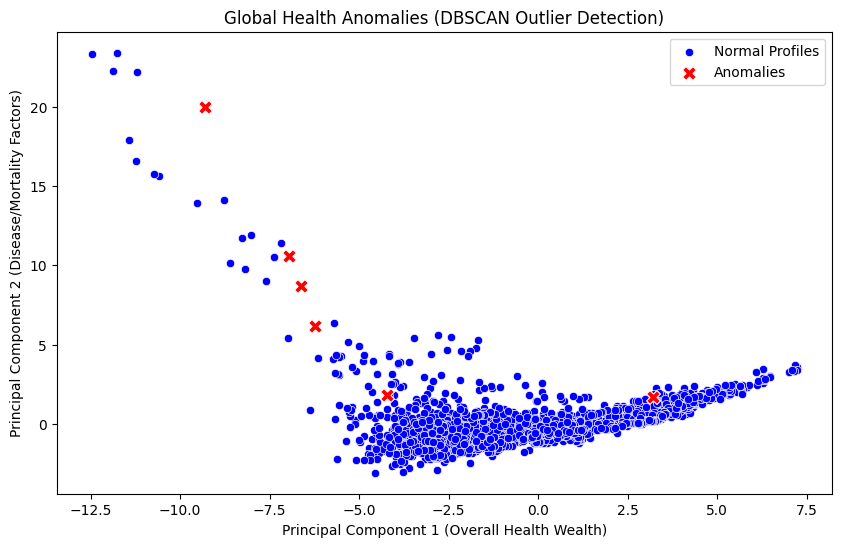

In [ ]:
# ---------------------------------------------------------
#7: Health Anomaly Detection (Advanced Clustering)
# ---------------------------------------------------------
from sklearn.cluster import DBSCAN

print("\n--- Performing DBSCAN Anomaly Detection ---")
# DBSCAN groups points that are packed closely together.
# Anything that falls outside these dense regions is labeled as '-1' (Noise/Anomaly).

dbscan = DBSCAN(eps=4.5, min_samples=3)
anomaly_labels = dbscan.fit_predict(X_scaled)

# Count how many anomalies were found
num_anomalies = list(anomaly_labels).count(-1)
print(f"DBSCAN discovered {num_anomalies} anomalous data points (outliers) in the global health data.")

# Visualize the anomalies using our previous PCA plot
plt.figure(figsize=(10, 6))
# Plot normal data points
sns.scatterplot(x=X_pca[anomaly_labels != -1, 0], y=X_pca[anomaly_labels != -1, 1], color='blue', label='Normal Profiles')
# Plot anomalies in red
sns.scatterplot(x=X_pca[anomaly_labels == -1, 0], y=X_pca[anomaly_labels == -1, 1], color='red', s=100, label='Anomalies', marker='X')

plt.title('Global Health Anomalies (DBSCAN Outlier Detection)')
plt.xlabel('Principal Component 1 (Overall Health Wealth)')
plt.ylabel('Principal Component 2 (Disease/Mortality Factors)')
plt.legend()
plt.show()


--- Running Policy Simulation: Sensitivity Analysis ---
Simulation Results: Increasing health expenditure by 10% globally yields:
-> An average life expectancy increase of 0.00 years per country.
-> A maximum observed increase of 0.09 years in the most highly-impacted nation.


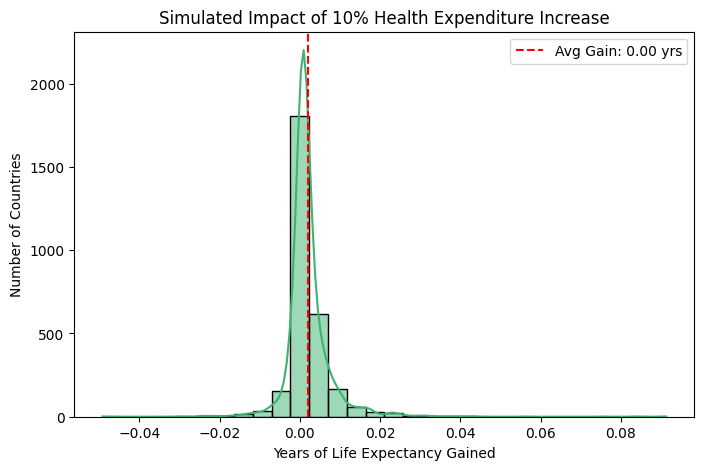

In [ ]:
# ---------------------------------------------------------
# 8. Policy Simulation: Sensitivity Analysis
# ---------------------------------------------------------

print("\n--- Running Policy Simulation: Sensitivity Analysis ---")

# 1. clean copy of the RAW imputed data
X_sim_boosted_raw = X_imputed.copy()

# 2. Apply the 10% increase to health expenditure
X_sim_boosted_raw['Total expenditure'] = X_sim_boosted_raw['Total expenditure'] * 1.10

# 3. Scale the data using the ORIGINAL scaler
X_sim_scaled_normal = pd.DataFrame(scaler.transform(X_imputed), columns=X_imputed.columns)
X_sim_scaled_boosted = pd.DataFrame(scaler.transform(X_sim_boosted_raw), columns=X_sim_boosted_raw.columns)

# 4.Drop the 'Life expectancy ' column
X_sim_ready_normal = X_sim_scaled_normal.drop(columns=['Life expectancy '])
X_sim_ready_boosted = X_sim_scaled_boosted.drop(columns=['Life expectancy '])

# 5. Predict using the FULL ENSEMBLE
baseline_predictions = reg_ensemble.predict(X_sim_ready_normal)
boosted_predictions = reg_ensemble.predict(X_sim_ready_boosted)

# 6. Calculate the real-world impact
impact = boosted_predictions - baseline_predictions
average_gain = impact.mean()
max_gain = impact.max()

print(f"Simulation Results: Increasing health expenditure by 10% globally yields:")
print(f"-> An average life expectancy increase of {average_gain:.2f} years per country.")
print(f"-> A maximum observed increase of {max_gain:.2f} years in the most highly-impacted nation.")

# 7. Visualize the impact distribution
plt.figure(figsize=(8, 5))
sns.histplot(impact, bins=30, kde=True, color='mediumseagreen')
plt.title('Simulated Impact of 10% Health Expenditure Increase')
plt.xlabel('Years of Life Expectancy Gained')
plt.ylabel('Number of Countries')
plt.axvline(x=average_gain, color='red', linestyle='--', label=f'Avg Gain: {average_gain:.2f} yrs')
plt.legend()
plt.show()